In [73]:
import joblib
import re

from IPython.display import Audio
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
 
from sklearn.metrics import label_ranking_average_precision_score

from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths
from birdclef_2026_ml.training.eval import (
    safe_multilabel_roc_auc,
    safe_singlelabel_average_precision,
    accuracy_at_k,
    precision_at_k,
    recall_at_k
)

paths = load_project_paths()
init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
filenames_subset = [
    "BC2026_Train_0006_S09_20250828_000000.ogg",
    "BC2026_Train_0065_S23_20241124_040002.ogg",
    "BC2026_Train_0038_S22_20211228_220000.ogg",
]

In [75]:
def print_metrics(y_true, y_proba, classes, k):
    roc_auc, _ = safe_multilabel_roc_auc(y_true, y_proba)
    macro_ap = safe_singlelabel_average_precision(y_true, y_proba, classes)
    lrap = label_ranking_average_precision_score(y_true, y_proba)
    
    acc = accuracy_at_k(y_true, y_proba, k)
    prec = precision_at_k(y_true, y_proba, k)
    rec = recall_at_k(y_true, y_proba, k)
    
    print(f"Top-{k} Accuracy:           {acc:.4f}")
    print(f"Top-{k} Precision:          {prec:.4f}")
    print(f"Top-{k} Recall:             {rec:.4f}")
    print(f"Macro ROC-AUC:              {roc_auc:.4f}")
    print(f"Macro Average Precision:    {macro_ap:.4f}")
    print(f"LRAP:                      {lrap:.4f}\n")

In [76]:
def plot_soundscape_chunk_topk(dataset, y_true, y_proba, filename, k=5, label_names=None):
    """Plot top-k predictions for all chunks of a soundscape file in a grid."""
    filenames = np.asarray(dataset.filenames)
    row_idxs = np.flatnonzero(filenames == filename)
    if row_idxs.size == 0:
        raise ValueError(f"Filename not found in dataset.filenames: {filename}")

    n_classes = y_proba.shape[1]
    if label_names is None:
        label_names = [str(i) for i in range(n_classes)]

    n_chunks = row_idxs.size
    max_cols = 5
    n_cols = min(max_cols, n_chunks)
    n_rows = int(np.ceil(n_chunks / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(max(6, n_cols * 3), max(4, n_rows * 3)),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for ax_id, (ax, row) in enumerate(zip(axes_flat, row_idxs), start=1):
        proba = y_proba[row]
        true_idx = np.flatnonzero(y_true[row] > 0)
        order = np.argsort(proba)[::-1]
        top_idx = order[:k]
        top_scores = proba[top_idx]
        top_labels = [label_names[i] for i in top_idx]

        missed = [idx for idx in true_idx if idx not in top_idx]
        missed_entries = []
        for idx in missed:
            rank = int(np.where(order == idx)[0][0]) + 1
            missed_entries.append(
                (idx, proba[idx], f"{label_names[idx]} (#{rank})")
            )
        missed_entries.sort(key=lambda item: item[1])

        top_entries = list(zip(top_idx, top_scores, top_labels))
        top_entries.sort(key=lambda item: item[1])

        plot_entries = missed_entries + top_entries
        plot_idx = [entry[0] for entry in plot_entries]
        plot_scores = [entry[1] for entry in plot_entries]
        plot_labels = [entry[2] for entry in plot_entries]

        for i, score in enumerate(plot_scores):
            if score > 0.12:
                x = score / 2
                ha = "center"
                color = "white"
            else:
                x = score + 0.02
                ha = "left"
                color = "black"

            ax.text(
                x,
                i,
                f"{score:.2f}",
                va="center",
                ha=ha,
                fontsize=8,
                color=color,
                fontweight="bold",
            )

        missed_set = {entry[0] for entry in missed_entries}
        colors = []
        for idx in plot_idx:
            if idx in missed_set:
                colors.append("#d62728")
            elif idx in true_idx:
                colors.append("#2ca02c")
            else:
                colors.append("#1f77b4")

        ax.barh(range(len(plot_scores)), plot_scores, color=colors)
        ax.set_yticks(range(len(plot_scores)))
        ax.set_yticklabels(plot_labels)
        ax.set_xlim(0, 1)
        ax.set_xlabel("probability")
        ax.set_title(f"Chunk {ax_id}")
        sns.despine(ax=ax, left=True, bottom=True)

        if missed_entries:
            ax.axhline(len(missed_entries) - 0.5, color="#999999", lw=0.8, alpha=0.8)

    for ax in axes_flat[n_chunks:]:
        ax.axis("off")

    fig.suptitle(filename)
    fig.tight_layout()
    return fig

In [77]:
le_class_name = joblib.load(paths.label_encoders_dir / "class_name.joblib")
le_primary_label = joblib.load(paths.label_encoders_dir / "primary_label.joblib")

primary_to_class = le_class_name.inverse_transform(np.load(paths.primary_to_class / "primary_to_class.npy"))

taxonomy = pd.read_csv(paths.taxonomy)
taxonomy_map = taxonomy.set_index("primary_label")["common_name"] 
idx = le_primary_label.transform(taxonomy_map.index)
values = taxonomy_map.values
taxonomy_map = values[np.argsort(idx)]

labels = [f"{pl} ({cn})" for pl, cn in zip(le_primary_label.classes_, primary_to_class)]

## 5 seconds chunks

In [84]:
run_name = "run_chunks_overlap"
experiment_name = "sgd_baseline"

dataset = load_memmap_dataset(run_name=run_name, reduced=True, soundscape=True)
experiment_dir = paths.experiment_dir(run_name, experiment_name)

raw_soft_proba = np.load(experiment_dir / "soundscapes" / "combined_proba.npy")
adapted_soft_proba = np.load(experiment_dir / "soundscapes" / "oof_proba.npy")

true_primary_label = dataset.y[:, 1, :]

In [85]:
classes = np.arange(len(le_primary_label.classes_))
print_metrics(true_primary_label, raw_soft_proba, classes, k=5)
print_metrics(true_primary_label, adapted_soft_proba, classes, k=5)

Top-5 Accuracy:           0.5074
Top-5 Precision:          0.1494
Top-5 Recall:             0.1768
Macro ROC-AUC:              0.6253
Macro Average Precision:    0.1329
LRAP:                      0.1248

Top-5 Accuracy:           0.0541
Top-5 Precision:          0.0111
Top-5 Recall:             0.0131
Macro ROC-AUC:              0.7398
Macro Average Precision:    0.2788
LRAP:                      0.1014



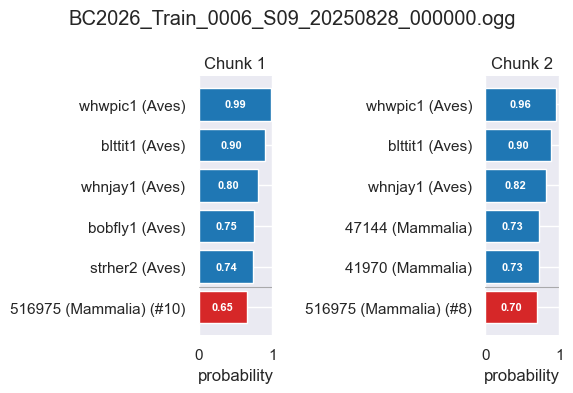

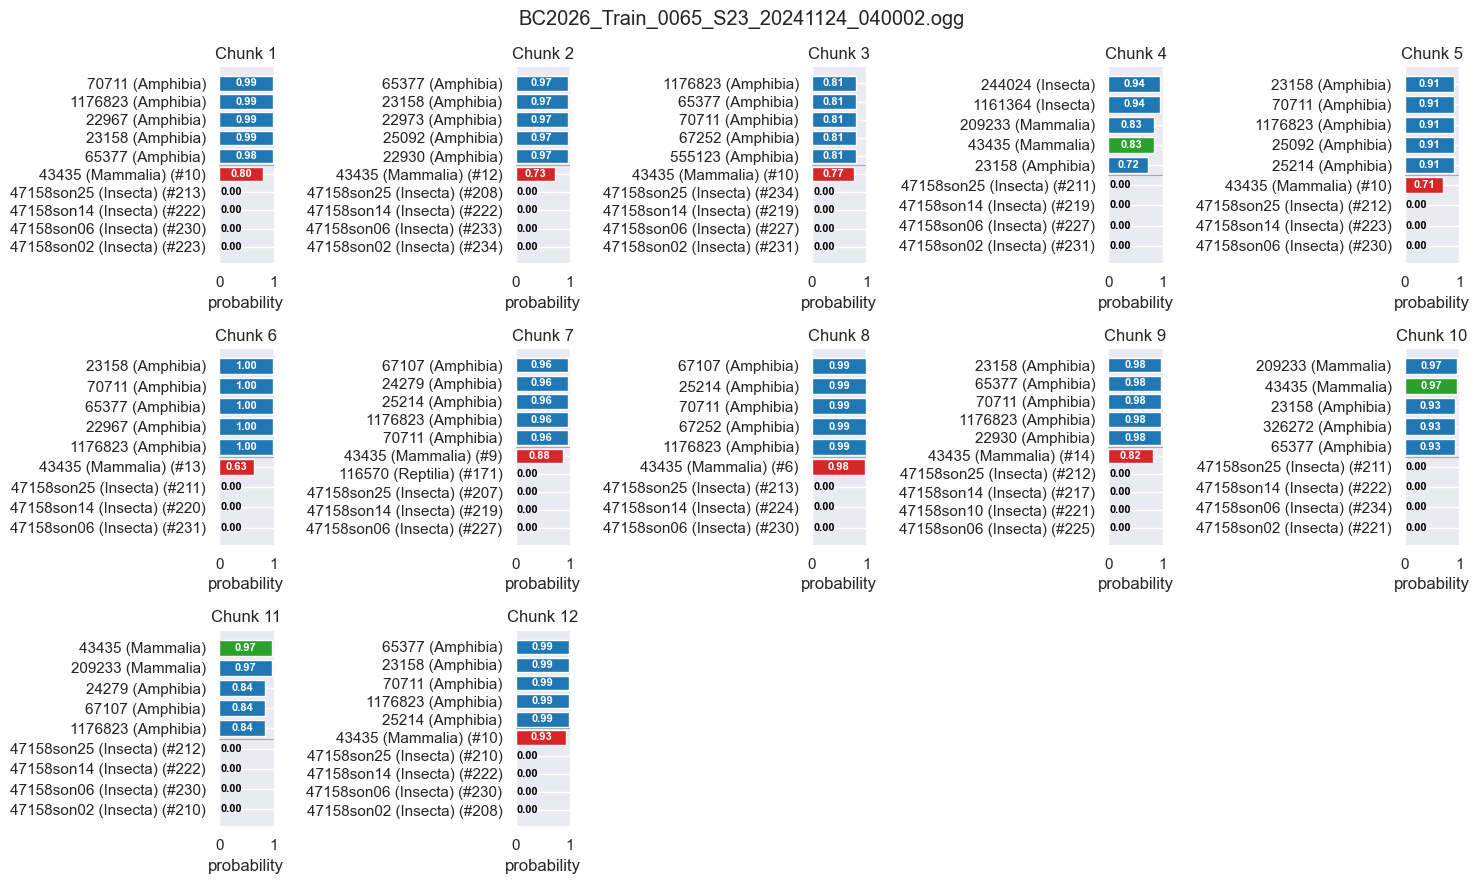

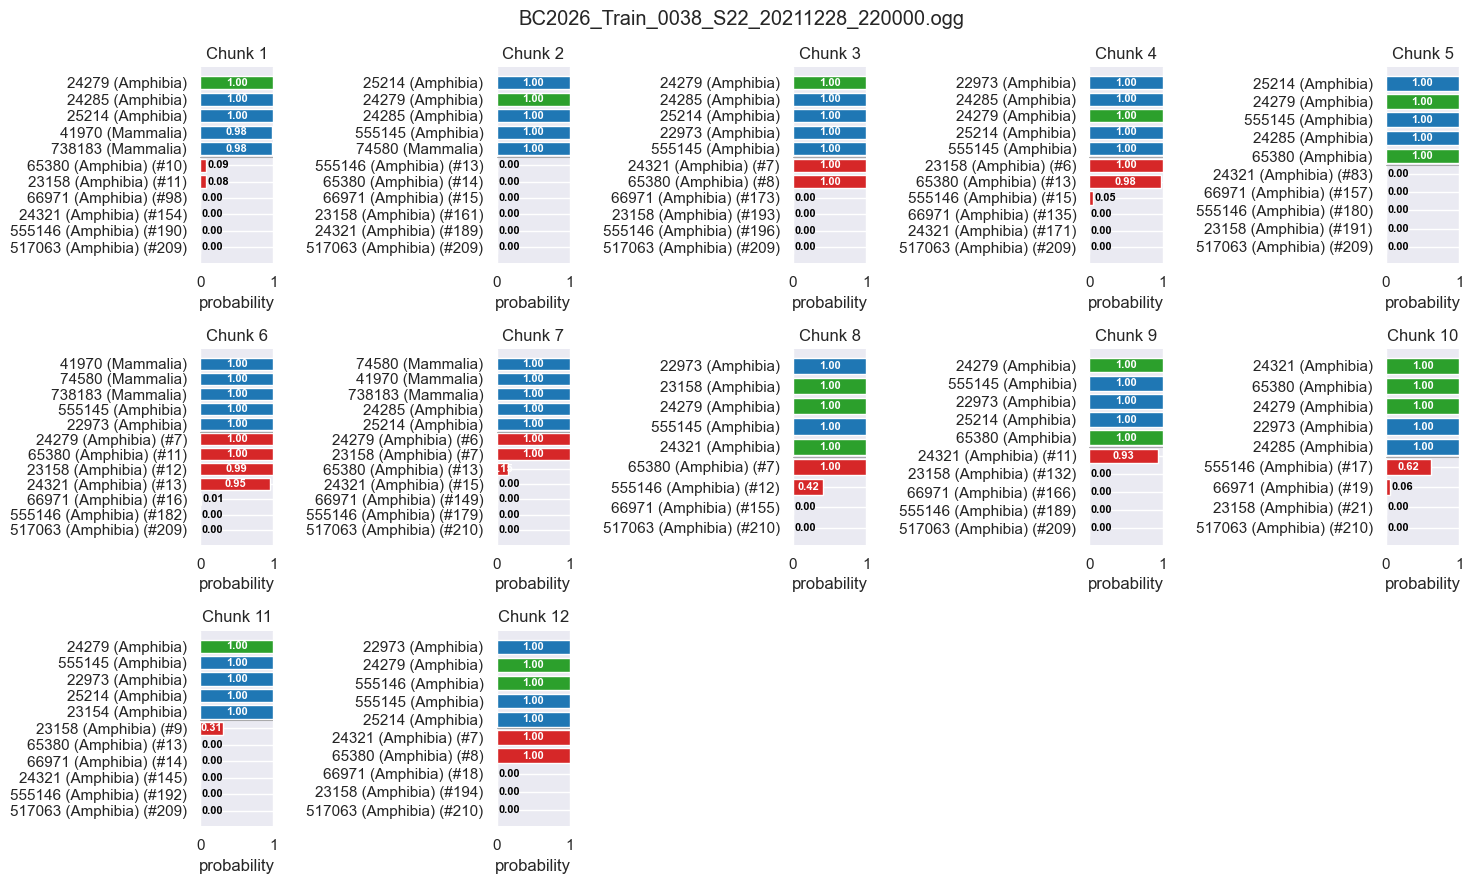

In [89]:
for f in filenames_subset:
    i = int(re.search(r"BC2026_Train_(\d{3,4})_", f).group(1))
    fig = plot_soundscape_chunk_topk(
        dataset,
        true_primary_label,
        raw_soft_proba,
        f,
        5,
        labels
    )
    fig.savefig(f"plots/evaluation/ss_raw_chunks_{i}.pdf", bbox_inches="tight")

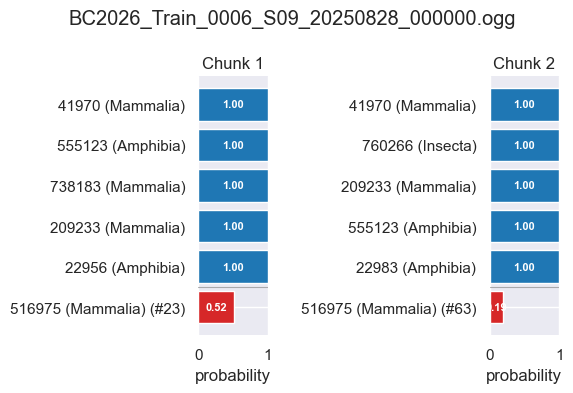

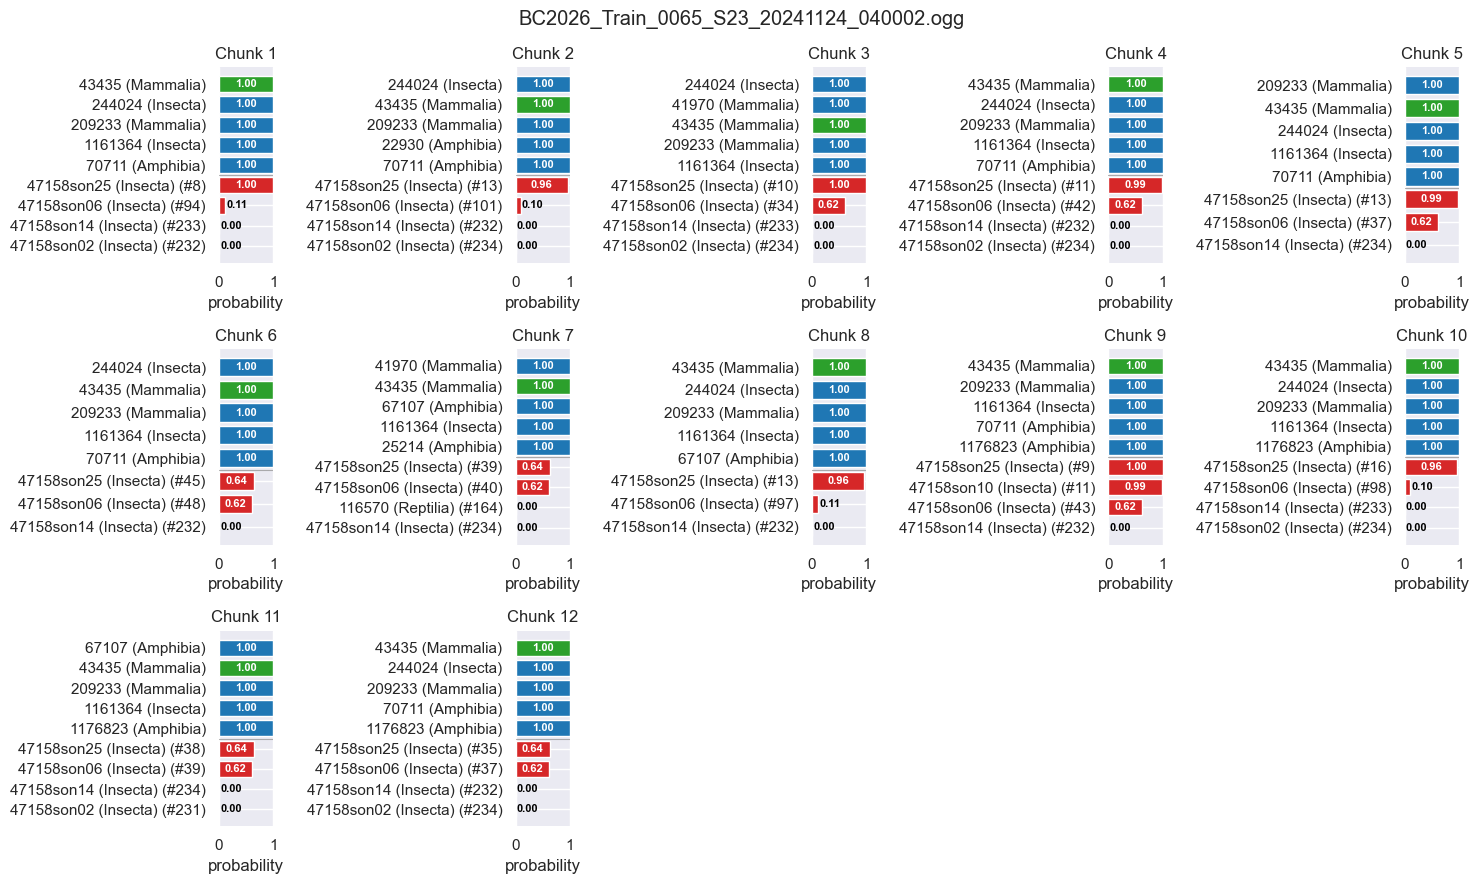

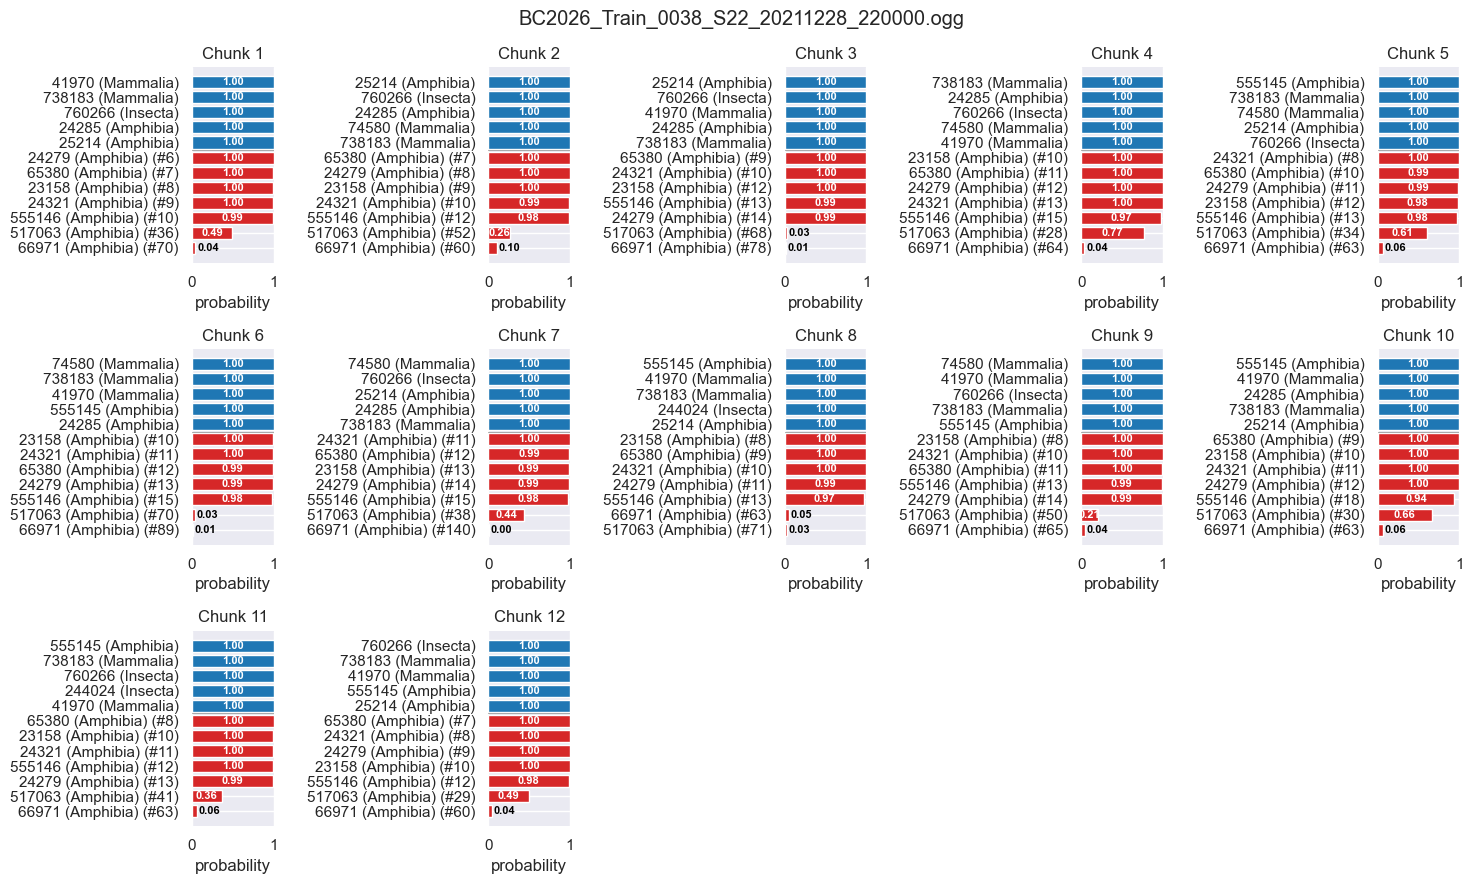

In [90]:
for f in filenames_subset:
    fig = plot_soundscape_chunk_topk(
        dataset,
        true_primary_label,
        adapted_soft_proba,
        f,
        5,
        labels
    )
    i = int(re.search(r"BC2026_Train_(\d{3,4})_", f).group(1))
    fig.savefig(f"plots/evaluation/ss_adapted_chunks_{i}.pdf", bbox_inches="tight")

## MIL

In [82]:
run_name = "run_mil"
experiment_name = "sgd_baseline"

dataset_mil = load_memmap_dataset(run_name=run_name, reduced=True, soundscape=True)
experiment_dir = paths.experiment_dir(run_name, experiment_name)

adapted_mil_proba = np.load(experiment_dir / "soundscapes" / "sgdclassifier_ovr_mil_second_stage_primary_soundscape_context_oof_raw.npy")
print_metrics(true_primary_label, adapted_mil_proba, classes, k=5)

Top-5 Accuracy:           0.6725
Top-5 Precision:          0.2936
Top-5 Recall:             0.3475
Macro ROC-AUC:              0.7487
Macro Average Precision:    0.2883
LRAP:                      0.3303



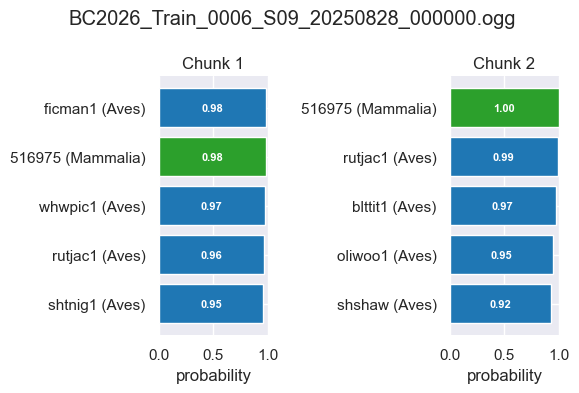

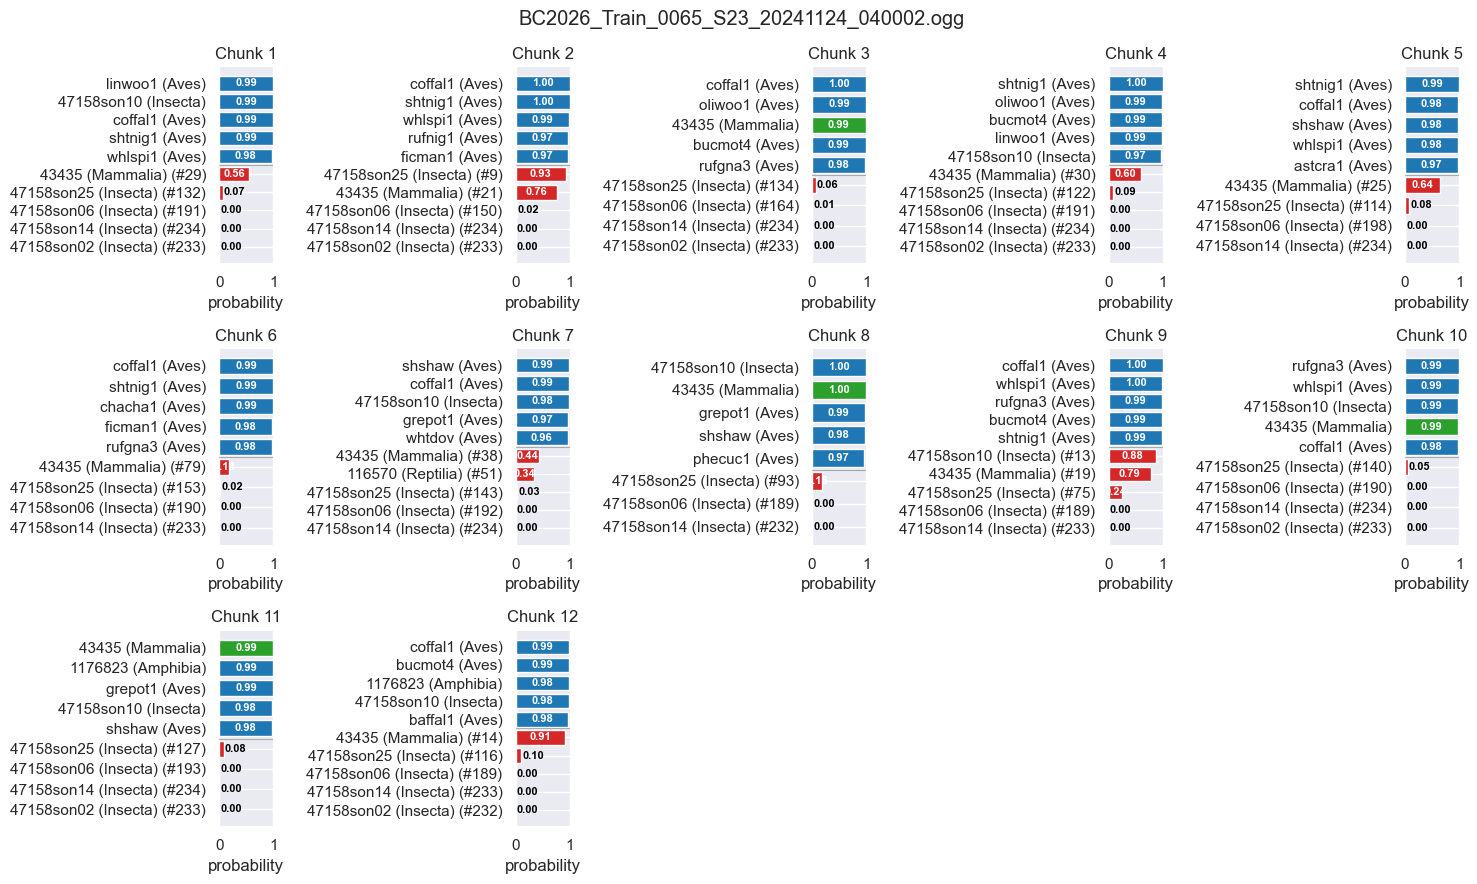

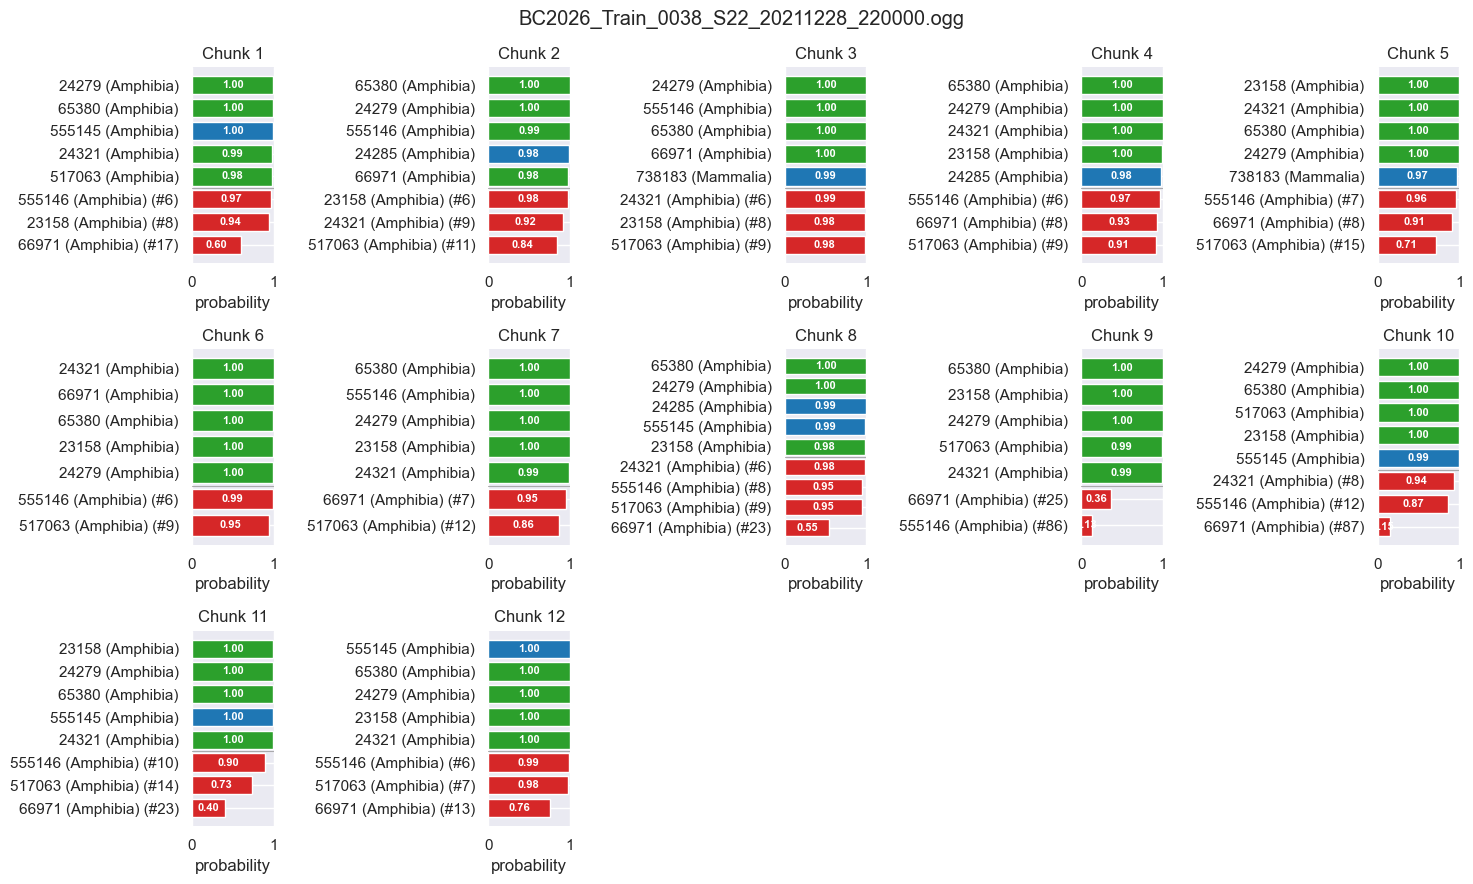

In [83]:
for f in filenames_subset:
    display(Audio(paths.soundscapes_clean_dir / f))
    fig = plot_soundscape_chunk_topk(
        dataset,
        true_primary_label,
        adapted_mil_proba,
        f,
        5,
        labels
    )
    
    i = int(re.search(r"BC2026_Train_(\d{3,4})_", f).group(1))
    fig.savefig(f"plots/evaluation/ss_mil_chunks_{i}.pdf", bbox_inches="tight")